In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingClassifier

from prepare_data import load_and_prepare
from model import GradientBoosting


In [3]:
X_train, X_test, y_train, y_test, feature_metadata, _ = load_and_prepare('weatherAUS.csv')

X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()

imputer = SimpleImputer(strategy='median')
X_train_np = imputer.fit_transform(X_train_np)
X_test_np = imputer.transform(X_test_np)

X_train_np, X_val_np, y_train, y_val = train_test_split(
    X_train_np, y_train, test_size=0.1, random_state=43, stratify=y_train
)

print('Train:', X_train_np.shape, 'Test:', X_test_np.shape)


Train: (102378, 21) Test: (28439, 21)


### Кастомная модель

In [4]:
custom_model = GradientBoosting(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=3,
    min_samples_leaf=5,
    subsample=0.8,
)

t0 = time.perf_counter()
custom_model.fit(X_train_np, y_train)
custom_train_time = time.perf_counter() - t0

custom_pred = custom_model.predict(X_val_np)
custom_metrics = {
    'accuracy': accuracy_score(y_val, custom_pred),
    'f1_weighted': f1_score(y_val, custom_pred, average='weighted'),
    'precision': precision_score(y_val, custom_pred),
    'recall': recall_score(y_val, custom_pred),
}

print('Custom train time:', round(custom_train_time, 3), 'sec')
print(custom_metrics)
print('Confusion matrix:\n', confusion_matrix(y_val, custom_pred))


Custom train time: 75.976 sec
{'accuracy': 0.8469585091420534, 'f1_weighted': 0.8333683599178043, 'precision': 0.7526545908806995, 'recall': 0.4725490196078431}
Confusion matrix:
 [[8430  396]
 [1345 1205]]


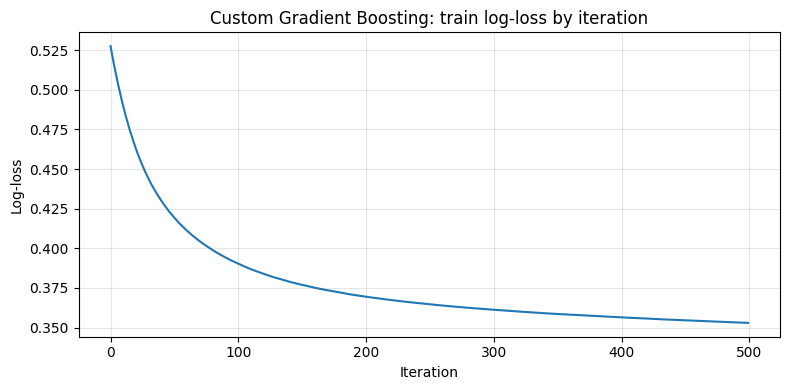

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(custom_model.train_losses_)
plt.title('Custom Gradient Boosting: train log-loss by iteration')
plt.xlabel('Iteration')
plt.ylabel('Log-loss')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Кросс-валидация

In [6]:
scoring = ['accuracy', 'f1_weighted', 'precision', 'recall']
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

custom_cv_model = GradientBoosting(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=3,
    min_samples_leaf=5,
    subsample=0.8,
)

cv_res = cross_validate(custom_cv_model, X_train_np, y_train, cv=cv, scoring=scoring, n_jobs=-1)
for score_type in scoring:
    print(score_type, np.mean(cv_res[f"test_{score_type}"]))


accuracy 0.8476626081912271
f1_weighted 0.8355354365153367
precision 0.7435583213734492
recall 0.4892389059014298


### Модель из sklearn

In [7]:
sk_model = GradientBoostingClassifier(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
)

t0 = time.perf_counter()
sk_model.fit(X_train_np, y_train)
sk_train_time = time.perf_counter() - t0

sk_pred = sk_model.predict(X_val_np)
sk_metrics = {
    'accuracy': accuracy_score(y_val, sk_pred),
    'f1_weighted': f1_score(y_val, sk_pred, average='weighted'),
    'precision': precision_score(y_val, sk_pred),
    'recall': recall_score(y_val, sk_pred),
}

print('Sklearn train time:', round(sk_train_time, 3), 'sec')
print(sk_metrics)
print('Confusion matrix:\n', confusion_matrix(y_val, sk_pred))


Sklearn train time: 86.751 sec
{'accuracy': 0.8559247538677919, 'f1_weighted': 0.8463306185399448, 'precision': 0.7540435025097602, 'recall': 0.5301960784313725}
Confusion matrix:
 [[8385  441]
 [1198 1352]]


### Кросс-валидация

In [8]:
scoring = ['accuracy', 'f1_weighted', 'precision', 'recall']
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

sk_cv_model = GradientBoostingClassifier(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
)

cv_res = cross_validate(sk_cv_model, X_train_np, y_train, cv=cv, scoring=scoring, n_jobs=-1)
for score_type in scoring:
    print(score_type, np.mean(cv_res[f"test_{score_type}"]))


accuracy 0.8562582044293316
f1_weighted 0.847195598982766
precision 0.750623488441862
recall 0.5374261283205893


In [9]:
comparison = pd.DataFrame([
    {
        'model': 'Custom GradientBoosting',
        'accuracy': custom_metrics['accuracy'],
        'f1_weighted': custom_metrics['f1_weighted'],
        'precision': custom_metrics['precision'],
        'recall': custom_metrics['recall'],
        'train_time_sec': custom_train_time,
    },
    {
        'model': 'sklearn GradientBoostingClassifier',
        'accuracy': sk_metrics['accuracy'],
        'f1_weighted': sk_metrics['f1_weighted'],
        'precision': sk_metrics['precision'],
        'recall': sk_metrics['recall'],
        'train_time_sec': sk_train_time,
    }
])
comparison


,model,accuracy,f1_weighted,precision,recall,train_time_sec
0,Custom GradientBoosting,0.846959,0.833368,0.752655,0.472549,75.975805
1,sklearn GradientBoostingClassifier,0.855925,0.846331,0.754044,0.530196,86.750567
